<a href="https://colab.research.google.com/github/claudrojasp-cmyk/mineria_datos_clases/blob/main/mineriaDatosEvaluaci%C3%B3n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluación 2 - Minería de Datos **

**Asignatura:** Minería de Datos  
**Sección:** 003D  
**Integrantes:** Claudio Rojas, Leandro Vergara  
**Fecha:** Mayo 2026

## **Objetivo**
Aplicar y comparar dos modelos de minería de datos sobre el dataset de ganadores de las 24 Horas de Le Mans (preprocesado en la Evaluación 1):
- **Regresión Lineal** (modelo paramétrico) para predecir la velocidad media (*Average_speed_kmh_mm*).
- **Árbol de Decisión** (modelo no paramétrico) para clasificar la nacionalidad del piloto ganador (*Driver_nationality_TOP*).

## **Requisitos de la presentación**
- Selección de más de un modelo.
- Justificación técnica según el tipo de variables.
- Análisis e interpretación de resultados.
- Comentarios sobre problemas y soluciones.

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Mostrar todas las filas
pd.set_option('display.max_rows', None)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [20]:
df = pd.read_csv('/content/LeMans_Procesado.csv')

**1. Preparación de los Datos.**
**Primero, definimos las características ($X$) y los objetivos ($y$) para cada modelo.**

In [21]:
# Definimos las variables predictoras (X) basándonos en tu lista
# Excluimos las variables objetivo y las redundantes (como mph_std si usamos kmh_std)
features = [
    'Year', 'Drivers_Frank Biela', 'Drivers_Henri Pescarolo', 'Drivers_Jacky Ickx',
    'Drivers_Other', 'Drivers_Tom Kristensen', 'Class_LE', 'Team_Joest Racing',
    'Team_Other', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari',
    'Team_Toyota Gazoo Racing', 'Car_Audi R18 e-tron quattro', 'Car_Audi R8',
    'Car_Other', 'Car_Porsche 919 Hybrid', 'Car_Toyota TS050 Hybrid',
    'Tyre_LE', 'Series_LE', 'Driver_nationality_FRA', 'Driver_nationality_GBR',
    'Driver_nationality_ITA', 'Driver_nationality_Other', 'Driver_nationality_USA',
    'Laps_std', 'Km_std'
]

X = df[features]

--- Evaluación Regresión Lineal ---
MSE: 0.0000
R2 Score: 1.0000


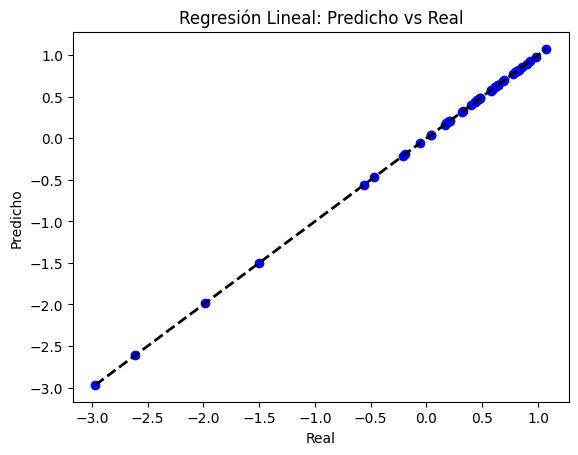

In [22]:
# Objetivo para Regresión
y_reg = df['Average_speed_kmh_std']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=29)

# Entrenamiento
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predicción y Evaluación
y_pred_lr = model_lr.predict(X_test)
print("--- Evaluación Regresión Lineal ---")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_lr):.4f}")

# Gráfico de resultados (Predicho vs Real)
plt.scatter(y_test, y_pred_lr, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Regresión Lineal: Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()


--- Evaluación Árbol de Decisión ---
Precisión (Accuracy): 0.7391
Reporte de Clasificación:
              precision    recall  f1-score   support

           1       0.78      0.95      0.86        22
           2       0.62      0.62      0.62         8
           3       0.83      0.42      0.56        12
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         1
           6       0.33      1.00      0.50         1

    accuracy                           0.74        46
   macro avg       0.76      0.75      0.70        46
weighted avg       0.77      0.74      0.73        46



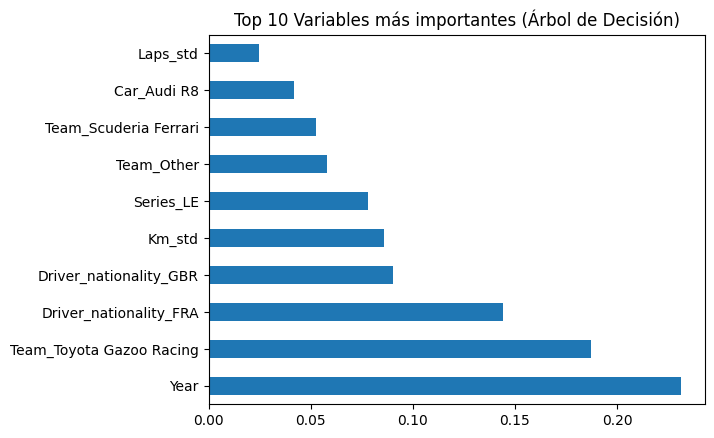

In [23]:

# Objetivo para Clasificación
y_clf = df['Team_nationality_LE']

# División de datos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Entrenamiento (Clasificador)
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train_c, y_train_c)

# Evaluación
y_pred_dt = model_dt.predict(X_test_c)
print("\n--- Evaluación Árbol de Decisión ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test_c, y_pred_dt):.4f}")
print("Reporte de Clasificación:")
print(classification_report(y_test_c, y_pred_dt))

# Visualización opcional de la importancia de las variables
importances = pd.Series(model_dt.feature_importances_, index=features)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Variables más importantes (Árbol de Decisión)")
plt.show()